<a href="https://colab.research.google.com/github/kanishka1114/fairness-auditor-ai/blob/main/AUDITING.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Installing Required Libraries

In [1]:
pip install pandas scikit-learn fairlearn matplotlib

Loading Dataset

In [2]:
import pandas as pd
from sklearn.datasets import fetch_openml

data = fetch_openml(name='adult', version=2, as_frame=True)

df = data.frame

print(df.head())

   age  workclass  fnlwgt     education  education-num      marital-status  \
0   25    Private  226802          11th              7       Never-married   
1   38    Private   89814       HS-grad              9  Married-civ-spouse   
2   28  Local-gov  336951    Assoc-acdm             12  Married-civ-spouse   
3   44    Private  160323  Some-college             10  Married-civ-spouse   
4   18        NaN  103497  Some-college             10       Never-married   

          occupation relationship   race     sex  capital-gain  capital-loss  \
0  Machine-op-inspct    Own-child  Black    Male             0             0   
1    Farming-fishing      Husband  White    Male             0             0   
2    Protective-serv      Husband  White    Male             0             0   
3  Machine-op-inspct      Husband  Black    Male          7688             0   
4                NaN    Own-child  White  Female             0             0   

   hours-per-week native-country  class  
0       

Data Preprocessing

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

df = df.dropna()

label = LabelEncoder()

for col in df.columns:
    # Modified condition to include 'category' dtype
    if df[col].dtype == 'object' or df[col].dtype.name == 'category':
        df[col] = label.fit_transform(df[col])

X = df.drop("class", axis=1)
y = df["class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

/tmp/ipykernel_13879/2478268472.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = label.fit_transform(df[col])
/tmp/ipykernel_13879/2478268472.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = label.fit_transform(df[col])
/tmp/ipykernel_13879/2478268472.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/

Training basic ML model ( LOGISTIC REGRESSION )

In [4]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit (X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

Evaluating Normal Performance

In [5]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

Accuracy: 0.8078496406854616
              precision    recall  f1-score   support

           0       0.83      0.94      0.88      6842
           1       0.68      0.40      0.50      2203

    accuracy                           0.81      9045
   macro avg       0.75      0.67      0.69      9045
weighted avg       0.79      0.81      0.79      9045



Fairness Auditing

In [6]:
sensitive_feature = X_test["sex"]

Fairness Metrics

In [7]:
from fairlearn.metrics import demographic_parity_difference
from fairlearn.metrics import equalized_odds_difference

dp = demographic_parity_difference(
    y_test,
    y_pred,
    sensitive_features=sensitive_feature
)

eo = equalized_odds_difference(
    y_test,
    y_pred,
    sensitive_features=sensitive_feature
)

print("Demographic Parity Difference:", dp)
print("Equalized Odds Difference:", eo)

Demographic Parity Difference: 0.12369928681302064
Equalized Odds Difference: 0.17608999373705259


Visualize Fairness

In [8]:
from fairlearn.metrics import MetricFrame
from sklearn.metrics import accuracy_score

metrics = MetricFrame(
    metrics=accuracy_score,
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=sensitive_feature
)

print(metrics.by_group)

sex
0    0.882997
1    0.771970
Name: accuracy_score, dtype: float64


Implementing Bias Mitigation

In [9]:
from fairlearn.reductions import ExponentiatedGradient
from fairlearn.reductions import DemographicParity

mitigator = ExponentiatedGradient(
    LogisticRegression(),
    constraints=DemographicParity()
)

mitigator.fit(X_train, y_train, sensitive_features=X_train["sex"])

y_pred_mitigated = mitigator.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Evaluating after mitigation

In [10]:
dp_after = demographic_parity_difference(
    y_test,
    y_pred_mitigated,
    sensitive_features=sensitive_feature
)

print("DP after mitigation:", dp_after)

DP after mitigation: 0.005171558401453488


Comparing performance (Small loss but more fair model.)

In [11]:
print("Original Accuracy:", accuracy_score(y_test, y_pred))
print("Fair Model Accuracy:", accuracy_score(y_test, y_pred_mitigated))

Original Accuracy: 0.8078496406854616
Fair Model Accuracy: 0.7813156440022112


Train Model
 ↓
Check fairness
 ↓
If bias > threshold
 ↓
Apply mitigation
 ↓
Generate report

Automated System Code

In [12]:
def fairness_pipeline(model, X_train, X_test, y_train, y_test, sensitive_feature):

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    dp = demographic_parity_difference(
        y_test,
        y_pred,
        sensitive_features=sensitive_feature
    )

    print("Initial DP:", dp)

    if abs(dp) > 0.1:

        print("Bias detected → applying mitigation")

        mitigator = ExponentiatedGradient(
            LogisticRegression(),
            constraints=DemographicParity()
        )

        mitigator.fit(X_train, y_train,
                      sensitive_features=X_train["sex"])

        y_pred = mitigator.predict(X_test)

    print("Final Accuracy:", accuracy_score(y_test, y_pred))

    return y_pred

pipeline

In [13]:
fairness_pipeline(
    LogisticRegression(),
    X_train,
    X_test,
    y_train,
    y_test,
    sensitive_feature
)

Initial DP: 0.047656763160921226
Final Accuracy: 0.7867330016583748


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


array([0, 0, 0, ..., 0, 0, 0])

In [14]:
print("Fairness Auditor Running Successfully")

Fairness Auditor Running Successfully


Adding Random Forest Model

In [15]:
from sklearn.ensemble import RandomForestClassifier

# Train Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Predictions
rf_pred = rf_model.predict(X_test)

Comparing Accuracy

In [16]:
from sklearn.metrics import accuracy_score

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred))
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

Logistic Regression Accuracy: 0.8078496406854616
Random Forest Accuracy: 0.8560530679933664


Computing Fairness for BOTH Models

In [17]:
from fairlearn.metrics import demographic_parity_difference, equalized_odds_difference

# Sensitive feature
sensitive_feature = X_test["sex"]

# Logistic Regression fairness
dp_logistic = demographic_parity_difference(
    y_test, y_pred, sensitive_features=sensitive_feature
)

eo_logistic = equalized_odds_difference(
    y_test, y_pred, sensitive_features=sensitive_feature
)

# Random Forest fairness
dp_rf = demographic_parity_difference(
    y_test, rf_pred, sensitive_features=sensitive_feature
)

eo_rf = equalized_odds_difference(
    y_test, rf_pred, sensitive_features=sensitive_feature
)

Printing results clearly

In [21]:
print("\n--- MODEL COMPARISON ---\n")

print("Logistic Regression:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("DP Difference:", dp_logistic)
print("EO Difference:", eo_logistic)

print("\nRandom Forest:")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("DP Difference:", dp_rf)
print("EO Difference:", eo_rf)


--- MODEL COMPARISON ---

Logistic Regression:
Accuracy: 0.8078496406854616
DP Difference: 0.12369928681302064
EO Difference: 0.17608999373705259

Random Forest:
Accuracy: 0.8560530679933664
DP Difference: 0.17296083523716588
EO Difference: 0.07578969343675224


Creating comparison tables

In [23]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, rf_pred)
    ],
    "DP Difference": [dp_logistic, dp_rf],
    "EO Difference": [eo_logistic, eo_rf]
})

print(results)

                 Model  Accuracy  DP Difference  EO Difference
0  Logistic Regression  0.807850       0.123699        0.17609
1        Random Forest  0.856053       0.172961        0.07579


Graph

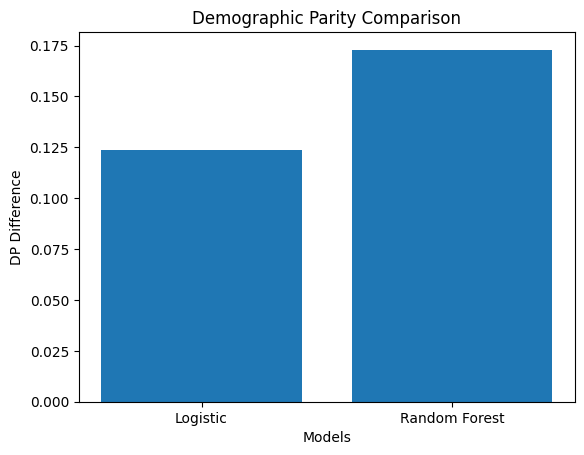

In [24]:
import matplotlib.pyplot as plt

models = ["Logistic", "Random Forest"]
dp_values = [dp_logistic, dp_rf]

plt.bar(models, dp_values)
plt.title("Demographic Parity Comparison")
plt.xlabel("Models")
plt.ylabel("DP Difference")
plt.show()